<a href="https://colab.research.google.com/github/ds-20195/notebooks/blob/main/drafts/Notebook8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%config InlineBackend.figure_formats = ["retina"]

In [2]:
!pip install -q folium scikit-learn census seaborn geopandas us

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 5.4 MB/s eta 0:00:00


In [3]:
!curl -OL https://raw.githubusercontent.com/ds-20195/notebooks/main/notebook_data/Notebook8_mappluto_subset.gpkg.zip
!unzip -o Notebook8_mappluto_subset.gpkg.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 13.0M  100 13.0M    0     0  25.4M      0 --:--:-- --:--:-- --:--:-- 25.4M
Archive:  Notebook8_mappluto_subset.gpkg.zip
  inflating: Notebook8_mappluto_subset.gpkg  


# Data and the State (DATA 20195/30195)
# Lab 8: Evictions

In [4]:
# FILL THIS IN WITH YOUR OWN CENSUS API KEY. You can get one for free at https://api.census.gov/data/key_signup.html
api_key = ""

In [5]:
import folium
import folium.plugins
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from census import Census

# The bit of logic below fixes an error caused by the Census changing it's API
# requirement on 12 May 2026. The Census package did not properly pass the API key to all
# requests, so we have to patch the element that handles that logic.
from functools import lru_cache
from census.core import Client

def _patched_field_type(self, field, year):
    url = self.definition_url % (year, self.dataset, field)
    resp = self.session.get(url, params={"key": self._key})

    type_map = {
        "fips-for": str,
        "fips-in": str,
        "int": float,
        "long": float,
        "float": float,
        "string": str,
    }
    if resp.status_code == 200:
        try:
            predicate_type = resp.json().get("predicateType", "string")
            return type_map.get(predicate_type, str)
        except Exception:
            return str
    return str


# Apply lru_cache and patch onto the base class
Client._field_type = lru_cache(maxsize=1024)(_patched_field_type)

In [6]:
year = 2018
if api_key == "":
    raise ValueError("You need to provide a Census API key to run this code. You can get one for free at https://api.census.gov/data/key_signup.html")

census = Census(key=api_key, year=year)

In [7]:
try:
    census.pl.get(
        ("NAME"),
        geo={"for": "state:17"},
        year=2020
    )
    print("Your request succeeded! The Census API is working with your API key.")
except Exception as e:
    print(f"Your request failed with error: {e}")

Your request succeeded! The Census API is working with your API key.


In [8]:
# @markdown This code cell contains a helper function for our backup data. Feel free to ignore.
import requests
import io
def read_parquet_from_github(url):
    # If there is no geometry data, then you need to read in with pandas or the
    # request will fail because geopandas expects to see a geometry column.
    r = requests.get(url)
    try:
        df = gpd.read_parquet(io.BytesIO(r.content))
    except ValueError:
        df = pd.read_parquet(io.BytesIO(r.content))
    return df

We'll start this week with data from the [Eviction Lab](https://evictionlab.org/) at Princeton, home of Matt Desmond and this week's guest Peter Hepburn. This data has been assembled and compiled from multiple sources, and more information on the methods they've used can be found [here](https://evictionlab.org/methods/). It is a powerful resource for studying eviction patterns throughout the United States.

To get a sense of what this data looks like interactively, you can explore their [interactive map](https://evictionlab.org/map).

We'll start with data for estimating eviction prevalence.  Each row is a county in a particular year, from 2000 to 2018.

In [9]:
df_eviction_prev = pd.read_csv(
    "https://eviction-lab-data-downloads.s3.amazonaws.com/estimating-eviction-prevalance-across-us/county_eviction_estimates_2000_2018.csv"
)
df_eviction_prev.head()

,state,county,FIPS_state,FIPS_county,year,renting_hh,filings_estimate,filings_ci_95_lower,filings_ci_95_upper,ind_filings_court_issued,ind_filings_court_issued_LT,hh_threat_estimate,hh_threat_95_lower,hh_threat_95_upper,ind_hht_observed
0,Alabama,Autauga County,1,1001,2000,3074,109,109,109,1,0.0,106,106,106,1
1,Alabama,Autauga County,1,1001,2001,3264,75,75,75,1,0.0,74,71,75,0
2,Alabama,Autauga County,1,1001,2002,3454,94,94,94,1,0.0,92,88,94,0
3,Alabama,Autauga County,1,1001,2003,3644,100,100,100,1,0.0,98,94,100,0
4,Alabama,Autauga County,1,1001,2004,3834,112,112,112,1,0.0,110,106,112,0


Next we'll calculate three measures that are common in the eviction literature and that the Eviction Lab reports.  These are a little confusing, so read carefully!

* *Eviction filing rate:* the total number of evictions *filed* per 100 renter-occupied homes in that area for a given year.  Note that this can reflect many filings on one apartment.
* *Households threatened rate:* the total number of renter-occupied households who ever received an eviction filing in a given year, per 100.
* *Eviction judgment rate:* the number of renters who received an eviction judgment/court order requiring them to leave over all renter-occupied homes in a given year.

So suppose there were 100 apartments in all, and 3 of them were filed on 5 times each, and out of those three, two resulted in a court order.  Then the filing rate would be 15, the threatened rate would be 3, and the eviction rate would be 2.  So these numbers should be ordered from largest to smallest.

Also notable:  they give two options for what dataset to use, which they call "Modeled" vs. "Original."  The "original" data comes from proprietary sources -- that means they largely bought it, and it's hard to vouch for the quality.  The "modeled" version uses official court data and smooths it out with some statistical tools.

Filing rate and threatened rate are both available from the modeled data.  Let's look at those first.

In [10]:
df_eviction_prev["filing_rate"] = (
    df_eviction_prev["filings_estimate"] * 100 / df_eviction_prev["renting_hh"]
)
df_eviction_prev["threatened_rate"] = (
    df_eviction_prev["hh_threat_estimate"] * 100 / df_eviction_prev["renting_hh"]
)

In [11]:
df_eviction_prev[["filing_rate", "threatened_rate"]].describe()

,filing_rate,threatened_rate
count,59717.000000,59717.000000
mean,5.010749,4.174013
std,7.472987,4.620251
min,0.000000,0.000000
25%,1.381999,1.351351
50%,2.810651,2.698651
75%,5.657193,5.190311
max,154.618193,59.569671


So there was some county that had a filing rate over 150 filings per 100 units -- more than one filing per housing unit! -- in a certain year.

Now we'll summarize this information across all 18 years of data. We'll first sum up the number of filings, threatened households and renting households, and then we'll reproduce our rates.

In [12]:
df_eviction_prev_overall = df_eviction_prev.groupby("FIPS_county")[
    ["filings_estimate", "hh_threat_estimate", "renting_hh"]
].sum()

df_eviction_prev_overall["filing_rate"] = (
    df_eviction_prev_overall["filings_estimate"] * 100 / df_eviction_prev_overall["renting_hh"]
)
df_eviction_prev_overall["threatened_rate"] = (
    df_eviction_prev_overall["hh_threat_estimate"] * 100 / df_eviction_prev_overall["renting_hh"]
)
df_eviction_prev_overall.head()

,filings_estimate,hh_threat_estimate,renting_hh,filing_rate,threatened_rate
FIPS_county,,,,,
1001,2492,2444,86450,2.882591,2.827068
1003,11869,11531,356720,3.327259,3.232507
1005,529,529,59900,0.883139,0.883139
1007,522,520,35274,1.479844,1.474174
1009,1154,1140,76355,1.511361,1.493026


In [13]:
# load counties shapefiles to map
gdf_counties = gpd.read_file(
    "https://raw.githubusercontent.com/ds-20195/notebooks/main/notebook_data/Notebook8_tl_2018_us_county.zip"
).to_crs(2163)
gdf_counties.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,31,039,00835841,31039,Cuming,Cuming County,06,H1,G4020,None,None,None,A,1477652222,10690952,+41.9158651,-096.7885168,"POLYGON ((246290.041 -328619.667, 246286.51 -3..."
1,53,069,01513275,53069,Wahkiakum,Wahkiakum County,06,H1,G4020,None,None,None,A,680956809,61588406,+46.2946377,-123.4244583,"POLYGON ((-1770686.984 398793.664, -1771124.91..."
2,35,011,00933054,35011,De Baca,De Baca County,06,H1,G4020,None,None,None,A,6016819484,29089486,+34.3592729,-104.3686961,"POLYGON ((-422754.447 -1210188.449, -422784.93..."
3,31,109,00835876,31109,Lancaster,Lancaster County,06,H1,G4020,339,30700,None,A,2169287528,22832516,+40.7835474,-096.6886584,"POLYGON ((260193.977 -463717.021, 260172 -4631..."
4,31,129,00835886,31129,Nuckolls,Nuckolls County,06,H1,G4020,None,None,None,A,1489645187,1718484,+40.1764918,-098.0468422,"POLYGON ((146978.459 -544334.301, 146978.432 -..."


Create unique indentifier.

In [14]:
gdf_counties["county_fips_full"] = (
    gdf_counties["STATEFP"] + gdf_counties["COUNTYFP"]
).astype(int)
gdf_counties.set_index("county_fips_full", inplace=True)

In [15]:
gdf_eviction_filings_overall = gdf_counties[
    ["STATEFP", "COUNTYFP", "NAME", "NAMELSAD", "geometry"]
].join(df_eviction_prev_overall, how="left")

Now we'll visualize on the map.  If we set the range to go up to the maximum (which is over 100) then most of the map will be washed out.  So we'll manually set the `vmax` to be 50.

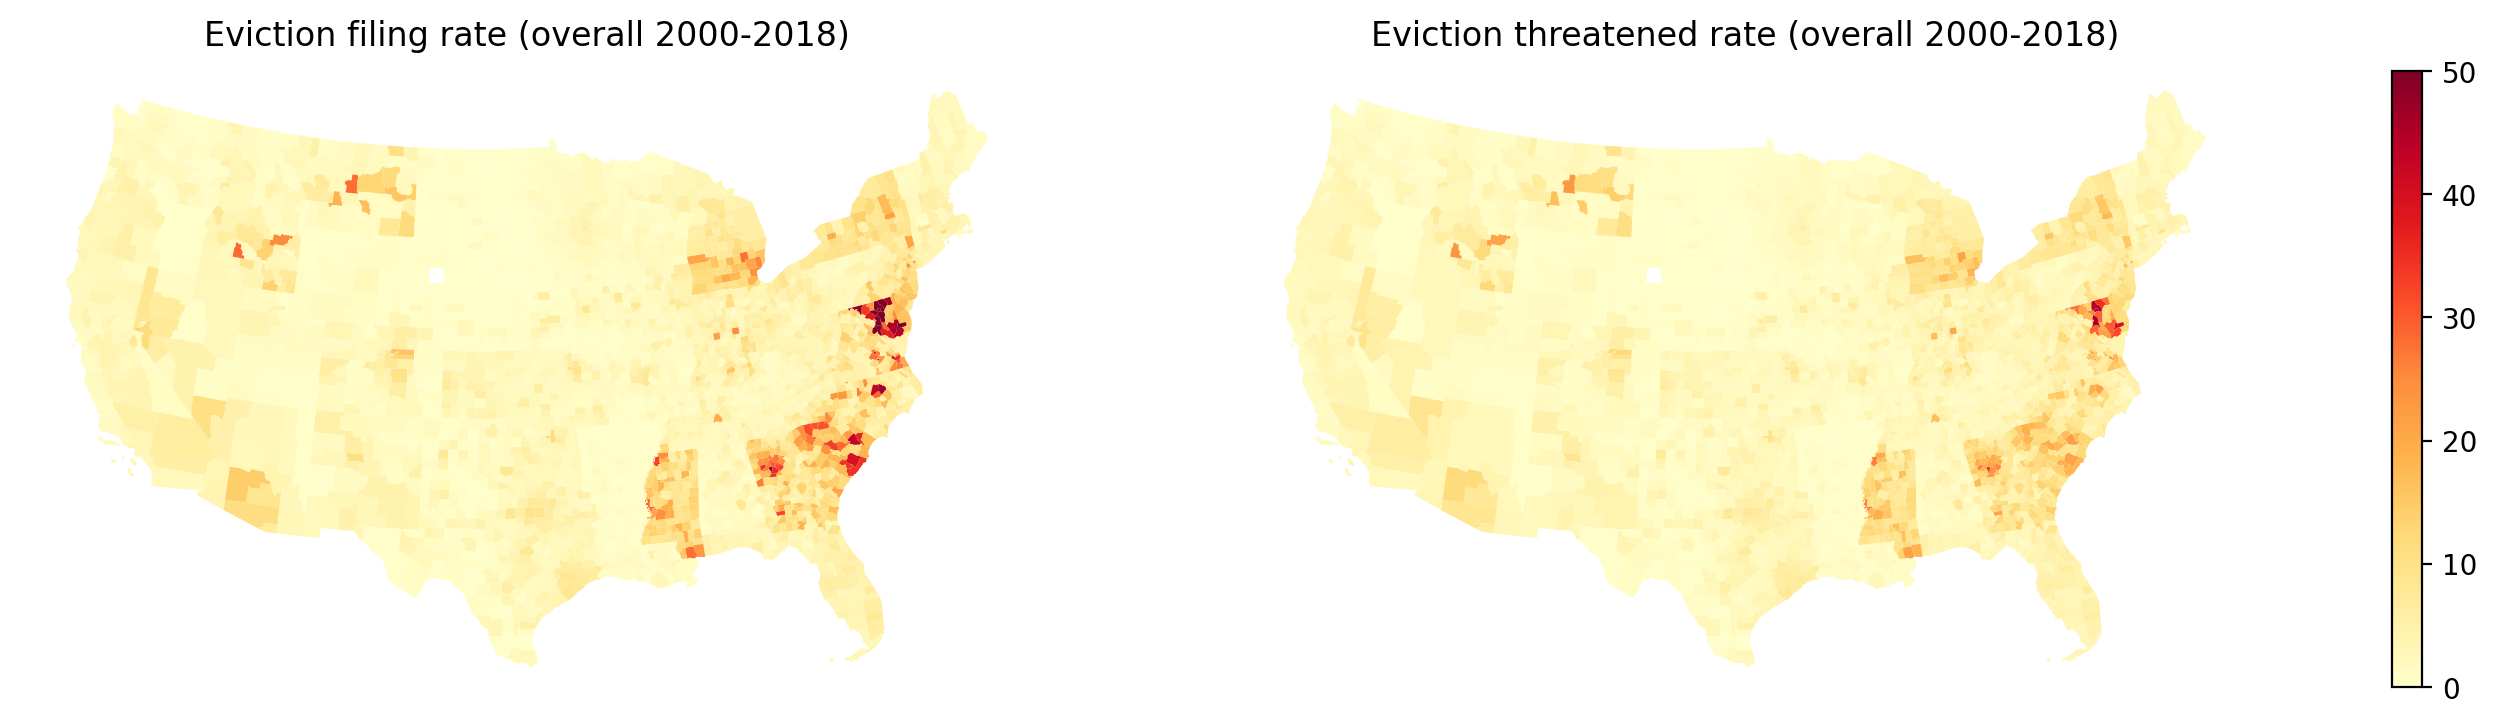

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
# filter out hawaii and alaska for visualization
state_filter = ~gdf_eviction_filings_overall.STATEFP.isin(["15", "02"])
gdf_eviction_filings_overall[state_filter].plot(
    column="filing_rate", ax=axes[0], vmin=0, vmax=50, cmap="YlOrRd", legend=False
)
gdf_eviction_filings_overall[state_filter].plot(
    column="threatened_rate", ax=axes[1], vmin=0, vmax=50, cmap="YlOrRd", legend=False
)
axes[0].set_title("Eviction filing rate (overall 2000-2018)")
axes[1].set_title("Eviction threatened rate (overall 2000-2018)")
axes[0].set_axis_off()
axes[1].set_axis_off()

# assume it's the first (and only) mappable
patch_col = axes[0].collections[0]
cb = fig.colorbar(patch_col, ax=axes, shrink=0.5)

What area had the highest filing rate (and is colored in a dark red in the mid-Atlantic region)?

In [17]:
gdf_eviction_filings_overall[
    gdf_eviction_filings_overall["filing_rate"]
    == gdf_eviction_filings_overall["filing_rate"].max()
]

,STATEFP,COUNTYFP,NAME,NAMELSAD,geometry,filings_estimate,hh_threat_estimate,renting_hh,filing_rate,threatened_rate
county_fips_full,,,,,,,,,,
24005,24,005,Baltimore,Baltimore County,"POLYGON ((1955260.174 -342141.577, 1955257.421...",2744606.0,885086.0,2014391.0,136.249914,43.938143


We can also look at some of the counties with eviction filing rates > 99th percentile.

In [18]:
gdf_eviction_filings_overall[
    gdf_eviction_filings_overall["filing_rate"]
    >= gdf_eviction_filings_overall["filing_rate"].quantile(0.99)
].sort_values("filing_rate", ascending=False)

,STATEFP,COUNTYFP,NAME,NAMELSAD,geometry,filings_estimate,hh_threat_estimate,renting_hh,filing_rate,threatened_rate
county_fips_full,,,,,,,,,,
24005,24,005,Baltimore,Baltimore County,"POLYGON ((1955260.174 -342141.577, 1955257.421...",2744606.0,885086.0,2014391.0,136.249914,43.938143
24033,24,033,Prince George's,Prince George's County,"POLYGON ((1964183.368 -398913.172, 1964168.607...",2644531.0,998469.0,2201214.0,120.139659,45.359924
24510,24,510,Baltimore,Baltimore city,"POLYGON ((1971826.798 -345975.085, 1971825.144...",2786282.0,1103890.0,2522676.0,110.449459,43.758691
24045,24,045,Wicomico,Wicomico County,"POLYGON ((2072705.275 -430164.685, 2072319.122...",189591.0,99849.0,253920.0,74.665643,39.323015
24025,24,025,Harford,Harford County,"POLYGON ((1988265.098 -324652.901, 1988253.165...",247483.0,126595.0,361361.0,68.486361,35.032834
24003,24,003,Anne Arundel,Anne Arundel County,"POLYGON ((1970416.791 -374960.982, 1970424.931...",627955.0,287406.0,978242.0,64.192194,29.379847
24027,24,027,Howard,Howard County,"POLYGON ((1948661.073 -368116.611, 1948639.104...",306100.0,133662.0,529348.0,57.825854,25.250308
24017,24,017,Charles,Charles County,"POLYGON ((1950169.833 -445836.699, 1950169.069...",112368.0,61700.0,209749.0,53.572603,29.416112
13063,13,063,Clayton,Clayton County,"POLYGON ((1436807.483 -1134446.214, 1436784.17...",353029.0,253199.0,734928.0,48.035862,34.452218


And we can compute the difference in filing and threatened rates difference between 2000 and 2018, to find out what counties experienced the greatest change in their filing rates over time.

In [19]:
df_eviction_prev.set_index("FIPS_county", inplace=True)
df_eviction_prev_wide = df_eviction_prev[
    df_eviction_prev["year"].isin([2000, 2018])
].pivot(columns="year", values=["threatened_rate", "filing_rate"])
df_eviction_prev_wide.columns = [
    a[0] + "_" + str(a[1]) for a in df_eviction_prev_wide.columns.to_flat_index()
]
df_eviction_prev_wide["filing_rate_diff"] = (
    df_eviction_prev_wide["filing_rate_2018"]
    - df_eviction_prev_wide["filing_rate_2000"]
)
df_eviction_prev_wide["threatened_rate_diff"] = (
    df_eviction_prev_wide["threatened_rate_2018"]
    - df_eviction_prev_wide["threatened_rate_2000"]
)

gdf_eviction_filings_diff = gdf_counties.join(df_eviction_prev_wide)
gdf_eviction_filings_diff.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,...,AWATER,INTPTLAT,INTPTLON,geometry,threatened_rate_2000,threatened_rate_2018,filing_rate_2000,filing_rate_2018,filing_rate_diff,threatened_rate_diff
county_fips_full,,,,,,,,,,,,,,,,,,,,,
31039,31,039,00835841,31039,Cuming,Cuming County,06,H1,G4020,None,...,10690952,+41.9158651,-096.7885168,"POLYGON ((246290.041 -328619.667, 246286.51 -3...",0.177148,0.424448,0.177148,0.424448,0.247300,0.247300
53069,53,069,01513275,53069,Wahkiakum,Wahkiakum County,06,H1,G4020,None,...,61588406,+46.2946377,-123.4244583,"POLYGON ((-1770686.984 398793.664, -1771124.91...",0.949367,1.818182,1.265823,1.818182,0.552359,0.868815
35011,35,011,00933054,35011,De Baca,De Baca County,06,H1,G4020,None,...,29089486,+34.3592729,-104.3686961,"POLYGON ((-422754.447 -1210188.449, -422784.93...",1.477833,2.429150,1.477833,2.429150,0.951317,0.951317
31109,31,109,00835876,31109,Lancaster,Lancaster County,06,H1,G4020,339,...,22832516,+40.7835474,-096.6886584,"POLYGON ((260193.977 -463717.021, 260172 -4631...",3.260454,3.390461,3.495165,3.643536,0.148371,0.130008
31129,31,129,00835886,31129,Nuckolls,Nuckolls County,06,H1,G4020,None,...,1718484,+40.1764918,-098.0468422,"POLYGON ((146978.459 -544334.301, 146978.432 -...",0.000000,0.179856,0.000000,0.179856,0.179856,0.179856


Now we can visualize where the rates rose and where they fell.  One good thing to think about for data like this is the [colormap](https://matplotlib.org/stable/users/explain/colors/colormaps.html).  So far we've been using a **sequential** colormap `YlOrRd`, which goes from yellow to orange to red.  But it's worth seeing how the map changes when you use a **divergent** colormap like `PuOr`.  

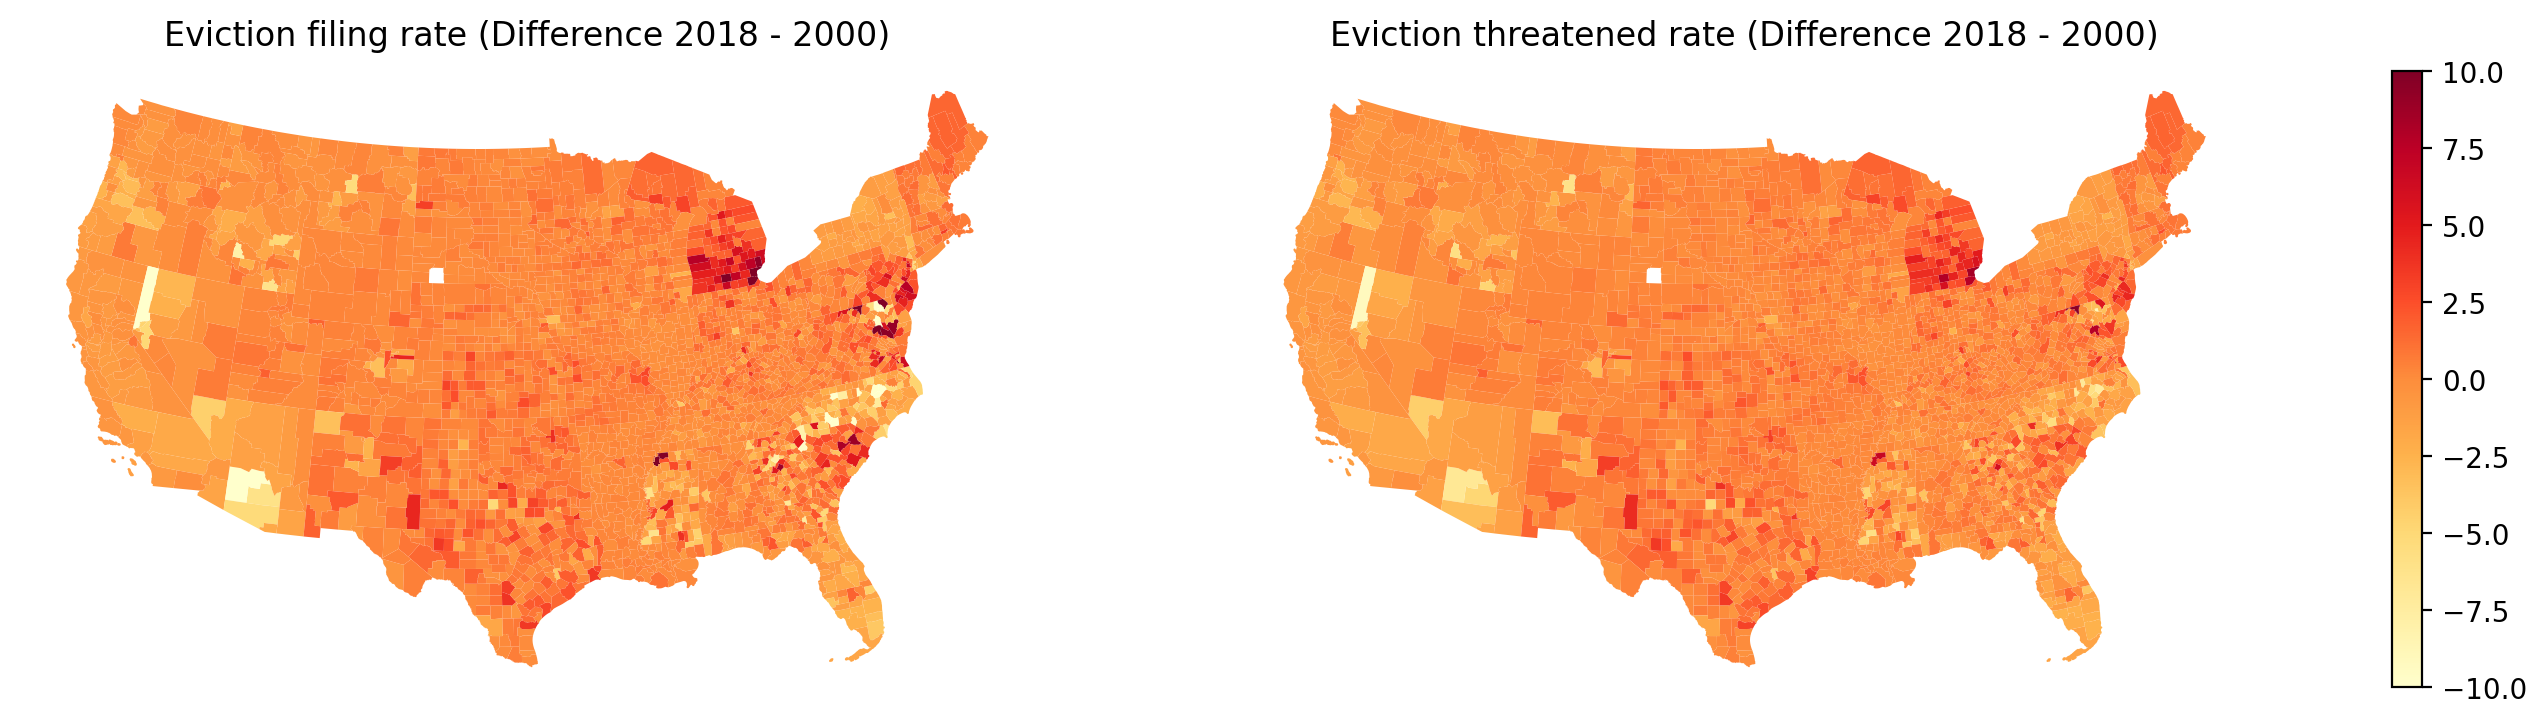

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
# filter out hawaii and alaska for visualization
state_filter = ~gdf_eviction_filings_diff.STATEFP.isin(["15", "02"])
gdf_eviction_filings_diff[state_filter].plot(
    column="filing_rate_diff",
    ax=axes[0],
    vmin=-10,
    vmax=10,
    cmap="YlOrRd",
    #cmap="PuOr",
    legend=False,
)
gdf_eviction_filings_diff[state_filter].plot(
    column="threatened_rate_diff",
    ax=axes[1],
    vmin=-10,
    vmax=10,
    cmap="YlOrRd",
    #cmap="PuOr",
    legend=False,
)
axes[0].set_title("Eviction filing rate (Difference 2018 - 2000)")
axes[1].set_title("Eviction threatened rate (Difference 2018 - 2000)")
axes[0].set_axis_off()
axes[1].set_axis_off()

# assume it's the first (and only) mappable
patch_col = axes[0].collections[0]
cb = fig.colorbar(patch_col, ax=axes, shrink=0.5)

Now we'll explore the **proprietary** data. The Eviction Lab shares this data on their map, but notes that it has limited coverage and there may be data quality issues. Additionally, these rates have already been produced without denominators, so we'll need to link back to the modeled data to get estimates of renting households.

In [21]:
df_proprietary = pd.read_csv(
    "https://eviction-lab-data-downloads.s3.amazonaws.com/estimating-eviction-prevalance-across-us/county_proprietary_2000_2018.csv"
)
df_proprietary.head()

,id,name,parent_location,year,type,filings,filing_rate,threatened,threatened_rate,judgements,judgement_rate
0,1001,Autauga County,Alabama,2000,observed,57.0,1.85,54.0,1.76,35.0,1.14
1,1001,Autauga County,Alabama,2001,observed,84.0,2.73,83.0,2.70,35.0,1.14
2,1001,Autauga County,Alabama,2002,observed,100.0,3.25,97.0,3.16,20.0,0.65
3,1001,Autauga County,Alabama,2003,observed,102.0,3.32,90.0,2.93,12.0,0.39
4,1001,Autauga County,Alabama,2004,observed,19.0,0.62,19.0,0.62,12.0,0.39


In [22]:
df_proprietary_overall = df_proprietary.merge(df_eviction_prev.reset_index()[["FIPS_county", "year", "renting_hh"]],
                                          left_on=["id", "year"],
                                          right_on = ["FIPS_county", "year"])\
                                          .groupby("id")[["filings", "threatened", "judgements", "renting_hh"]].sum()

df_proprietary_overall["filing_rate"] = (
    df_proprietary_overall["filings"] * 100 / df_proprietary_overall["renting_hh"]
)
df_proprietary_overall["threatened_rate"] = (
    df_proprietary_overall["threatened"] * 100 / df_proprietary_overall["renting_hh"]
)
df_proprietary_overall["judgement_rate"] = (
    df_proprietary_overall["judgements"] * 100 / df_proprietary_overall["renting_hh"]
)
df_proprietary_overall.head()

,filings,threatened,judgements,renting_hh,filing_rate,threatened_rate,judgement_rate
id,,,,,,,
1001,2009.0,1903.0,1108.0,86450,2.323887,2.201272,1.281666
1003,10054.0,9739.0,5602.0,356720,2.818457,2.730153,1.570419
1005,481.0,474.0,263.0,59900,0.803005,0.791319,0.439065
1007,314.0,309.0,174.0,35274,0.890174,0.875999,0.493281
1009,1025.0,1008.0,730.0,76355,1.342414,1.320149,0.956061


In [23]:
gdf_proprietary = gdf_counties.join(df_proprietary_overall, how="left")

In [24]:
gdf_proprietary.columns

Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'NAME', 'NAMELSAD', 'LSAD',
       'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'ALAND',
       'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry', 'filings', 'threatened',
       'judgements', 'renting_hh', 'filing_rate', 'threatened_rate',
       'judgement_rate'],
      dtype='object')

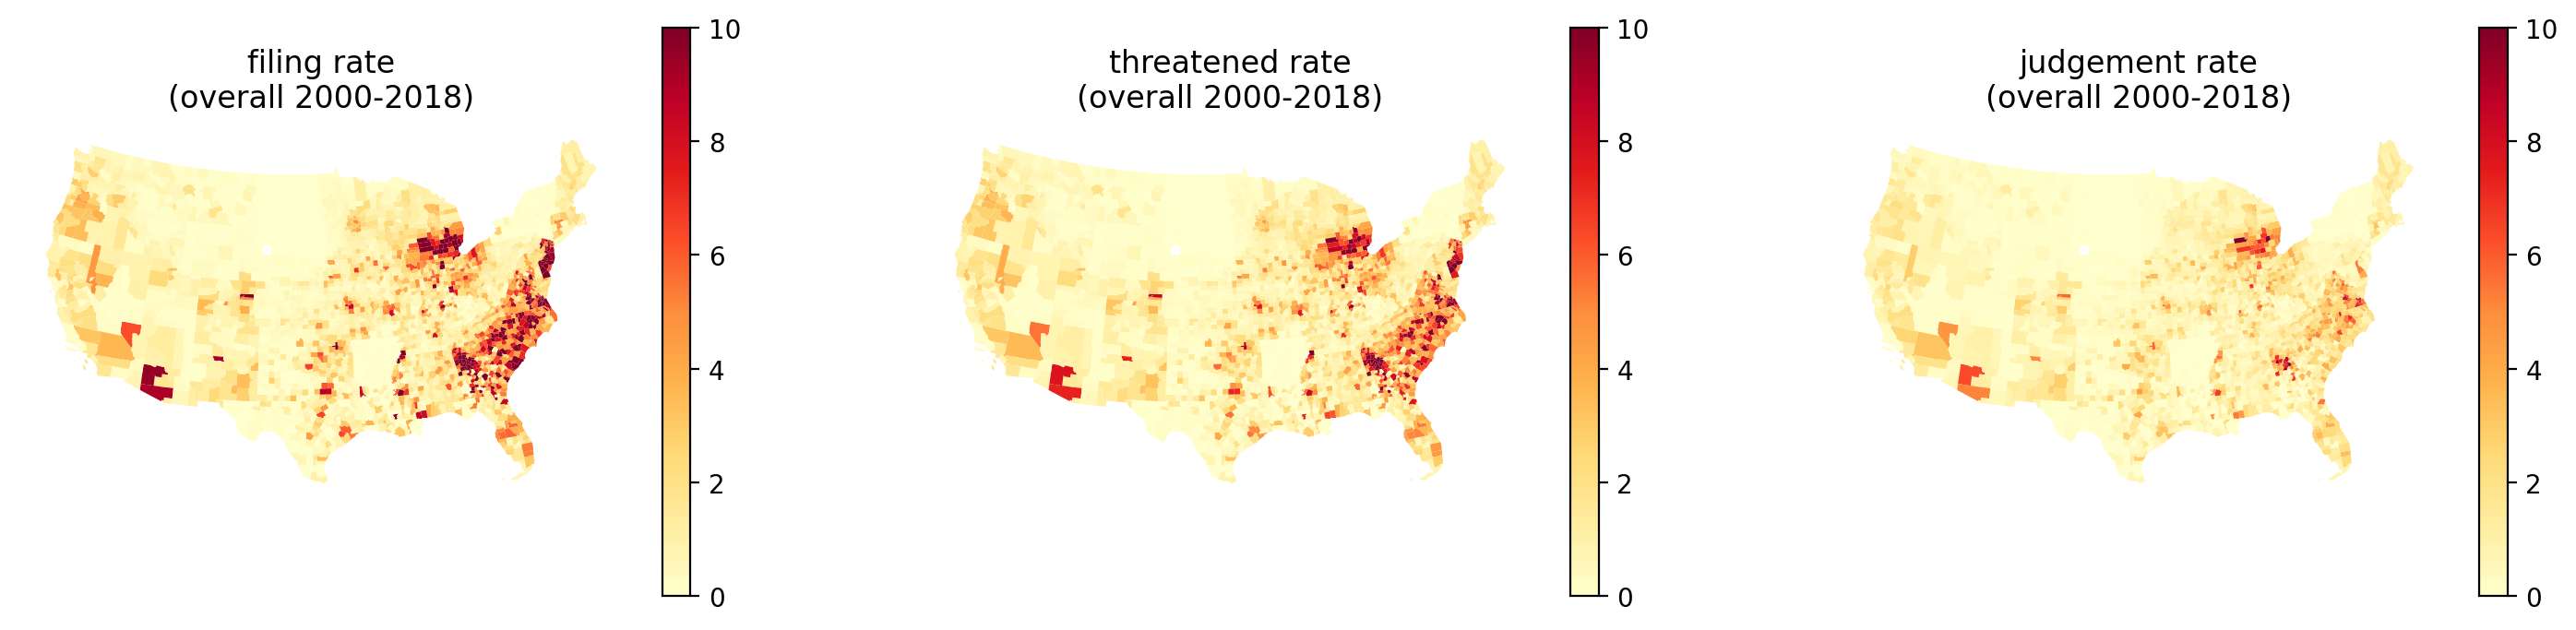

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
# filter out hawaii and alaska for visualization
for i, col in enumerate(["filing_rate", "threatened_rate", "judgement_rate"]):
    state_filter = ~gdf_proprietary.STATEFP.isin(["15", "02"])
    gdf_proprietary[state_filter].plot(
        column=col,
        vmax=10,
        ax=axes[i],
        cmap="YlOrRd",
        legend=True,
        legend_kwds={"shrink": 0.5},
    )

    axes[i].set_title(f"{col.replace('_',' ')}\n(overall 2000-2018)")
    axes[i].set_axis_off()

Please note that there are a lot of states completely (or almost entirely) missing from this data!  This includes the Dakotas, Arkansas, Vermont, and New York.  

Let's try comparing the modeled data to the proprietary data. It looks like the proprietary data might be undercounting the eviction filing rates and threatened rates.

In [26]:
df_eviction_mgd = df_eviction_prev.reset_index().merge(
    df_proprietary,
    left_on=["FIPS_county", "year"],
    right_on=["id", "year"],
    suffixes=["_modeled", "_proprietary"],
)

For example, what's happening in Baltimore county?  Let's compare the filing rates in the two ways Eviction Lab provides them.

In [27]:
df_eviction_mgd[df_eviction_mgd["FIPS_county"] == 24005][
    ["year", "filing_rate_modeled", "filing_rate_proprietary"]
]

,year,filing_rate_modeled,filing_rate_proprietary
22724,2000,121.373512,0.03
22725,2001,118.785111,0.19
22726,2002,125.663771,0.02
22727,2003,122.091880,0.02
22728,2004,123.634952,0.04
22729,2005,125.206232,0.35
22730,2006,131.876556,0.63
22731,2007,140.623602,2.02
22732,2008,141.270577,71.71
22733,2009,154.618193,21.37


In [28]:
df_eviction_mgd[df_eviction_mgd["FIPS_county"] == 24005][
    ["year", "threatened_rate_modeled", "threatened_rate_proprietary"]
]

,year,threatened_rate_modeled,threatened_rate_proprietary
22724,2000,39.097412,0.03
22725,2001,36.800465,0.18
22726,2002,39.235539,0.02
22727,2003,39.196403,0.02
22728,2004,43.462503,0.04
22729,2005,46.355005,0.33
22730,2006,47.269768,0.58
22731,2007,46.493822,1.97
22732,2008,46.983345,22.98
22733,2009,47.646106,10.58


This proprietary data gives a **huge** undercount compared to their modeling!

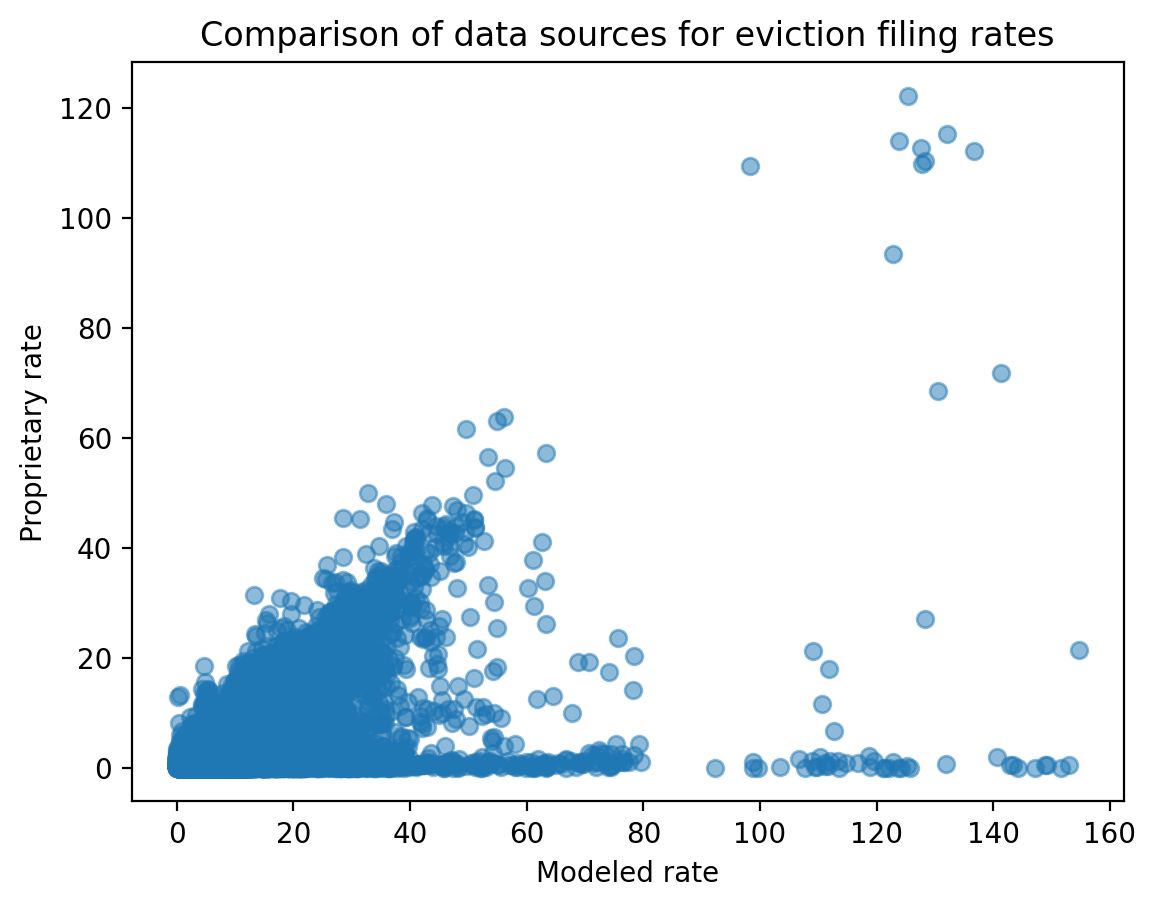

In [29]:
plt.scatter(
    df_eviction_mgd["filing_rate_modeled"],
    df_eviction_mgd["filing_rate_proprietary"],
    alpha=0.5,
)
plt.xlabel("Modeled rate")
plt.ylabel("Proprietary rate")
plt.title("Comparison of data sources for eviction filing rates")
plt.show()

## Comparison to Census Data

Let's load some county level ACS data.

In [30]:
acs_cols = [
    "B02001_001E",
    "B02001_002E",
    "B02001_003E",
    "B02001_004E",
    "B02001_005E",
    "B02001_006E",
    "B02001_007E",
    "B02001_008E",
    "B03002_012E",
    "B25038_001E",
    "B25038_009E",
    "B25031_001E",
]
acs_colnames = [
    "totalpop",
    "white",
    "black",
    "aian",
    "asian",
    "nhpi",
    "other",
    "multi",
    "hispanic_latino",
    "totalhh",
    "renters",
    "median_gross_rent",
]

In [31]:
try:
    county_acs_df = pd.DataFrame(
        census.acs5.get(
            tuple(acs_cols),
            geo={
                "for": "county:*",
                "in": "state:*",
            },
        )
    )
except Exception:
    county_acs_df = read_parquet_from_github(
        "https://github.com/ds-20195/notebooks/raw/refs/heads/main/notebook_data/Notebook8_county_acs_df.parquet",
    )

In [32]:
county_acs_df_clean = county_acs_df.rename(
    columns={x: y for x, y in zip(acs_cols, acs_colnames)}
)
county_acs_df_clean["GEOID10"] = (
    county_acs_df_clean["state"] + county_acs_df_clean["county"]
).astype(int)
county_acs_df_clean.set_index("GEOID10", inplace=True)
county_acs_df_clean.head()

,totalpop,white,black,aian,asian,nhpi,other,multi,hispanic_latino,totalhh,renters,median_gross_rent,state,county
GEOID10,,,,,,,,,,,,,,
20173,512064.0,400828.0,45888.0,5077.0,22209.0,226.0,16451.0,21385.0,73527.0,195779.0,71205.0,803.0,20,173
20157,4686.0,4576.0,16.0,17.0,30.0,0.0,0.0,47.0,87.0,2248.0,575.0,589.0,20,157
20065,2545.0,2319.0,100.0,5.0,25.0,0.0,0.0,96.0,77.0,1216.0,251.0,529.0,20,065
20045,119319.0,98478.0,5047.0,2935.0,6229.0,27.0,1337.0,5266.0,7356.0,46294.0,22293.0,897.0,20,045
20179,2506.0,2456.0,11.0,5.0,0.0,0.0,25.0,9.0,120.0,1134.0,298.0,605.0,20,179


In [33]:
county_acs_df_clean["renters_pct"] = (
    100 * county_acs_df_clean["renters"] / county_acs_df_clean["totalhh"]
)

race_eth_cols = [
    "white",
    "black",
    "aian",
    "asian",
    "nhpi",
    "other",
    "multi",
    "hispanic_latino",
]
for col in race_eth_cols:
    county_acs_df_clean[col + "_pct"] = (
        100 * county_acs_df_clean[col] / county_acs_df_clean["totalpop"]
    )

Let's merge on the Census ACS data.

In [34]:
county_acs_df_clean

,totalpop,white,black,aian,asian,nhpi,other,multi,hispanic_latino,totalhh,...,county,renters_pct,white_pct,black_pct,aian_pct,asian_pct,nhpi_pct,other_pct,multi_pct,hispanic_latino_pct
GEOID10,,,,,,,,,,,,,,,,,,,,,
20173,512064.0,400828.0,45888.0,5077.0,22209.0,226.0,16451.0,21385.0,73527.0,195779.0,...,173,36.370091,78.276934,8.961380,0.991478,4.337153,0.044135,3.212684,4.176236,14.358947
20157,4686.0,4576.0,16.0,17.0,30.0,0.0,0.0,47.0,87.0,2248.0,...,157,25.578292,97.652582,0.341443,0.362783,0.640205,0.000000,0.000000,1.002988,1.856594
20065,2545.0,2319.0,100.0,5.0,25.0,0.0,0.0,96.0,77.0,1216.0,...,065,20.641447,91.119843,3.929273,0.196464,0.982318,0.000000,0.000000,3.772102,3.025540
20045,119319.0,98478.0,5047.0,2935.0,6229.0,27.0,1337.0,5266.0,7356.0,46294.0,...,045,48.155269,82.533377,4.229838,2.459793,5.220459,0.022628,1.120526,4.413379,6.164986
20179,2506.0,2456.0,11.0,5.0,0.0,0.0,25.0,9.0,120.0,1134.0,...,179,26.278660,98.004789,0.438947,0.199521,0.000000,0.000000,0.997606,0.359138,4.788508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16003,4019.0,3852.0,11.0,50.0,0.0,8.0,4.0,94.0,141.0,1675.0,...,003,19.402985,95.844737,0.273700,1.244091,0.000000,0.199054,0.099527,2.338890,3.508335
16053,23431.0,22059.0,29.0,113.0,129.0,83.0,605.0,413.0,8299.0,7828.0,...,053,36.088401,94.144509,0.123768,0.482267,0.550553,0.354232,2.582049,1.762622,35.418890
16061,3845.0,3352.0,9.0,280.0,54.0,1.0,27.0,122.0,171.0,1632.0,...,061,28.492647,87.178153,0.234070,7.282185,1.404421,0.026008,0.702211,3.172952,4.447334


In [35]:
gdf_eviction_filings_demo = gdf_eviction_filings_overall.join(county_acs_df_clean)

# let's also set sentinel values for median gross rent
gdf_eviction_filings_demo["median_gross_rent"] = np.where(
    gdf_eviction_filings_demo["median_gross_rent"] < 0,
    np.nan,
    gdf_eviction_filings_demo["median_gross_rent"],
)

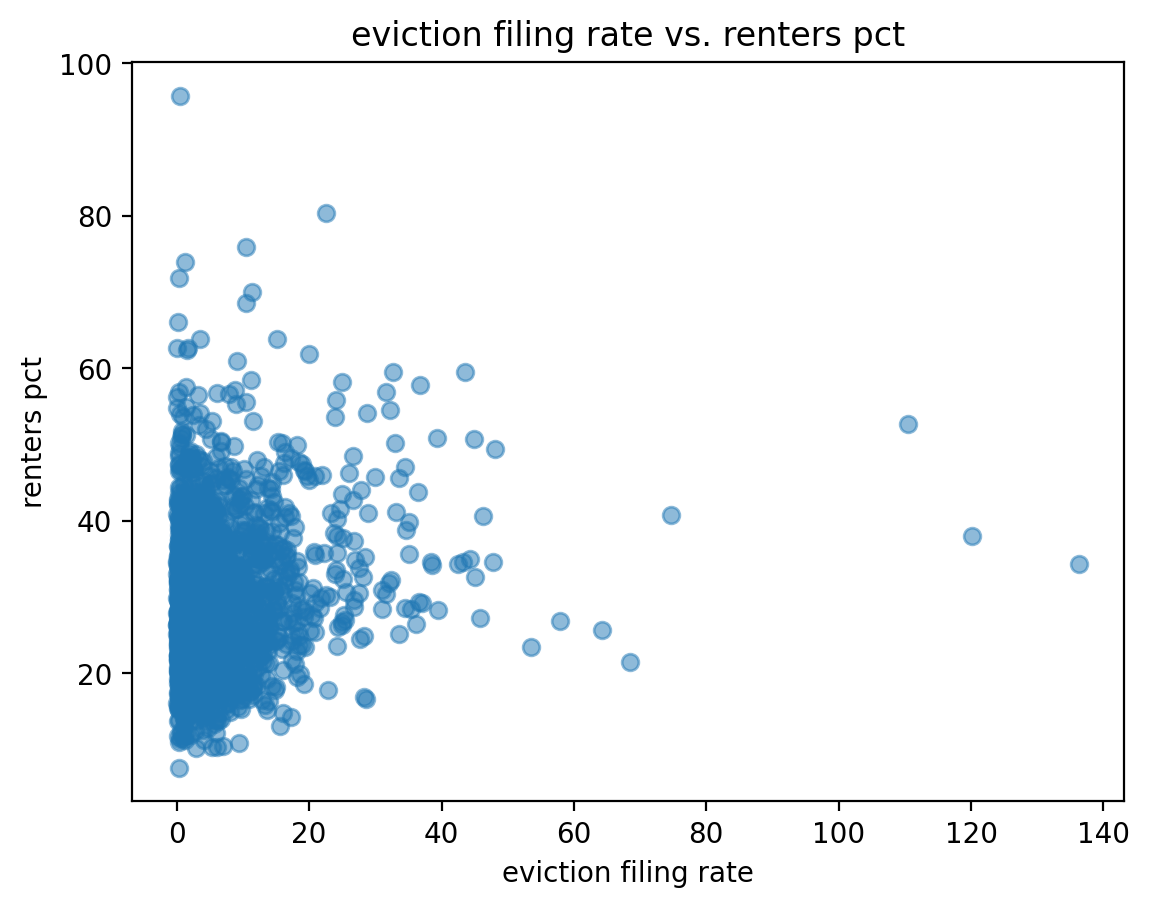

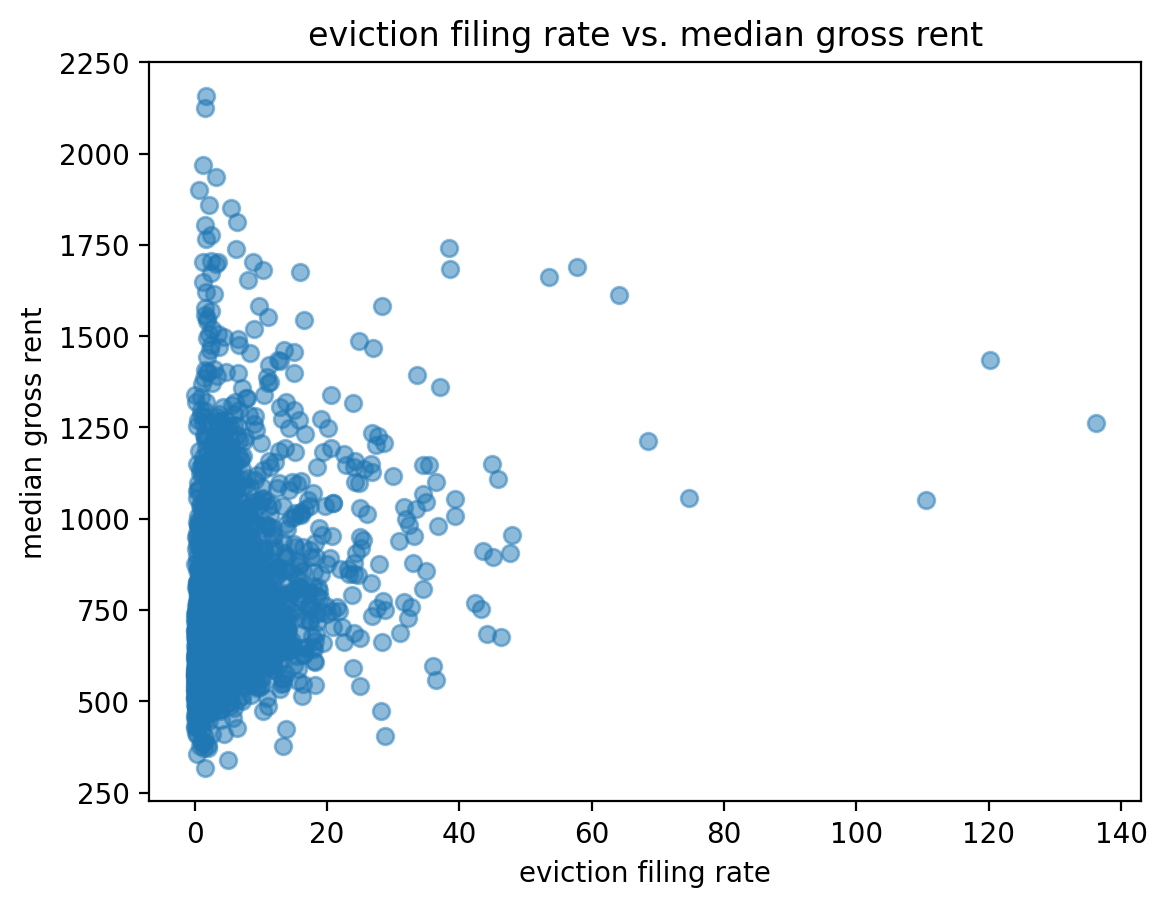

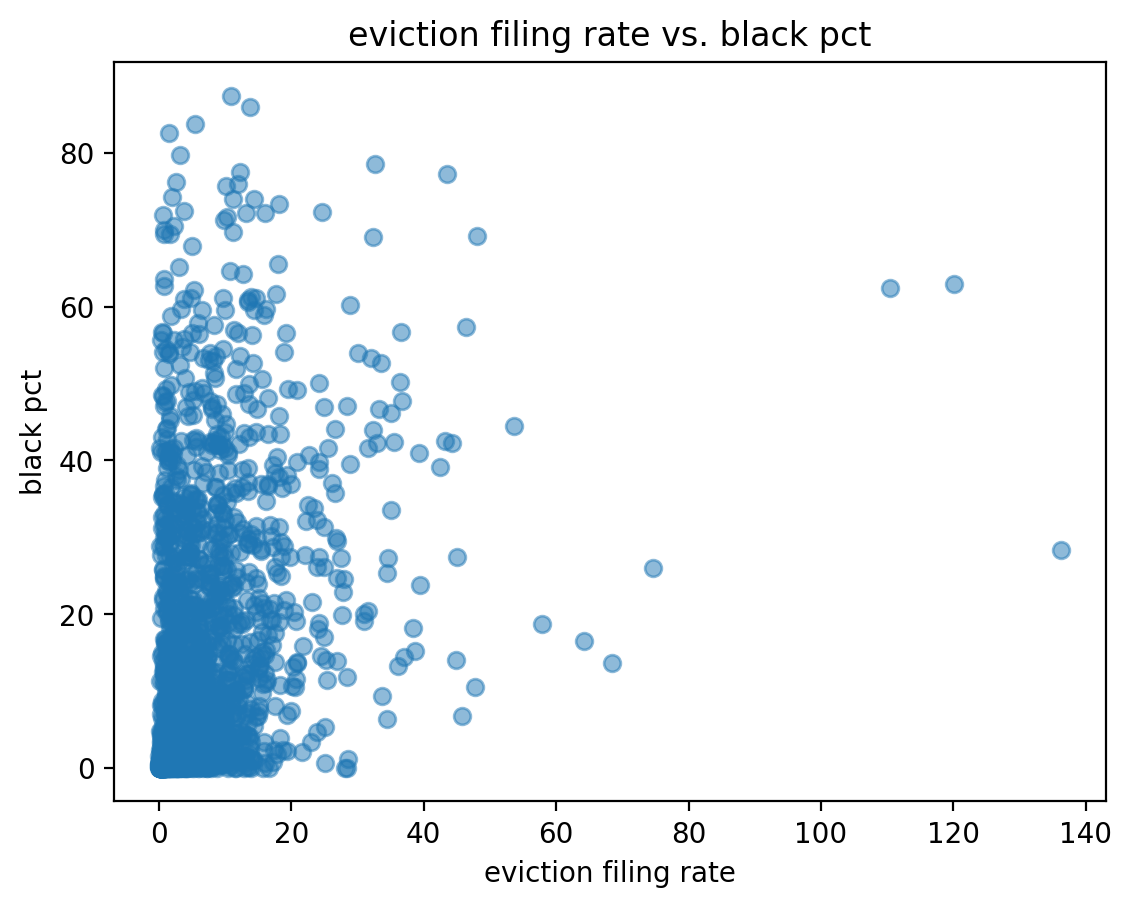

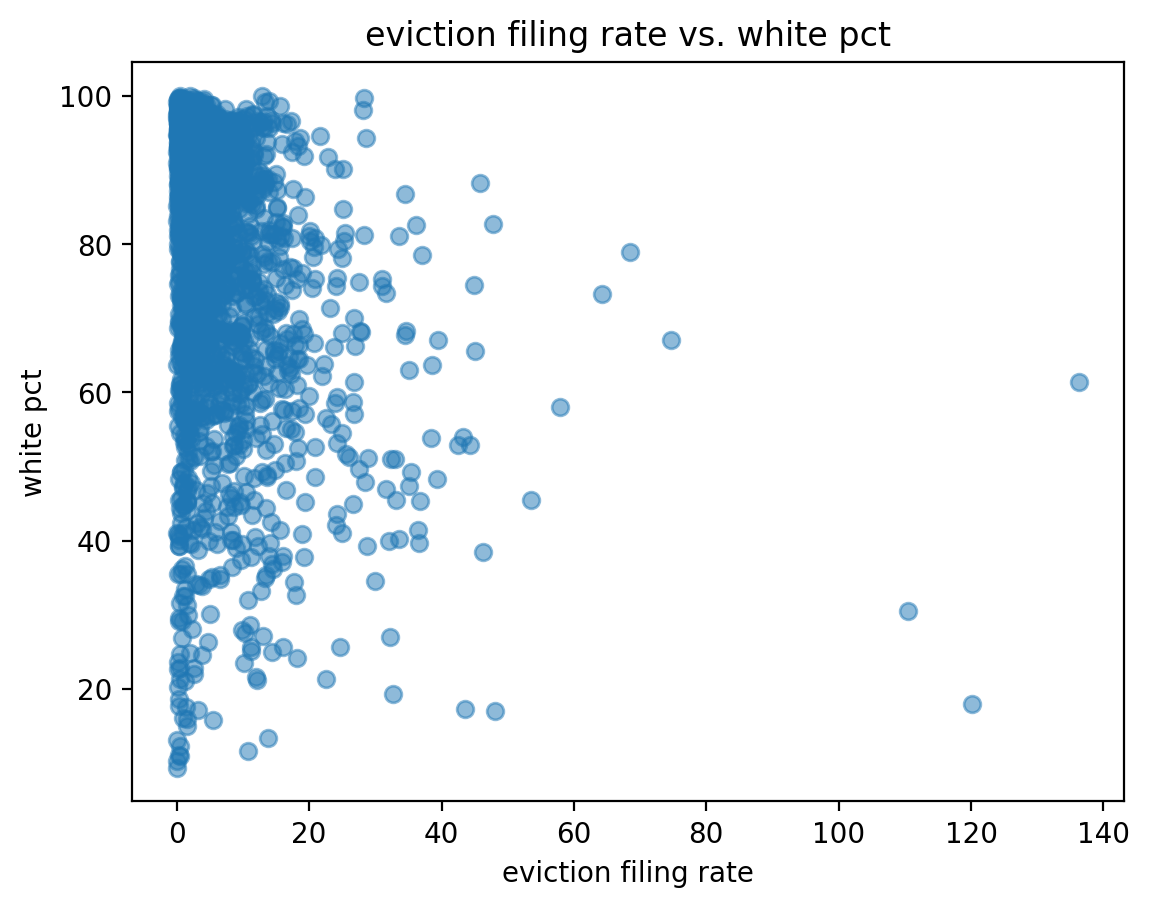

In [36]:
# just exploring a subset of columns
for col in ["renters_pct", "median_gross_rent", "black_pct", "white_pct"]:
    plt.scatter(
        gdf_eviction_filings_demo["filing_rate"],
        gdf_eviction_filings_demo[col],
        alpha=0.5,
    )
    plt.xlabel("eviction filing rate")
    plt.ylabel(col.replace("_", " "))
    plt.title(f"eviction filing rate vs. {col.replace('_', ' ')}")
    plt.show()

## Eviction Data: NYC Open Data

The Eviction Lab provides a comprehensive resource on evictions, but it's not the only resource on evictions. We can also use local data. For example, New York City publishes an [Open Data set](https://data.cityofnewyork.us/City-Government/Evictions/6z8x-wfk4/about_data) on *executed* evictions (that go through the court system and result in physical removal). This is building-level data on evictions going back to 2017.

Eviction data in general is challenging to obtain and often subject to specific state and local policies. For example, the New York State OCA Data Collective receives housing court filings data from the state Office of Court Administration and shares this with local organizations like the [Housing Data Coalition](https://www.housingdatanyc.org/). The OCA Data Collective includes organizations like the Right to Counsel Coalition, BetaNYC, the Association for Neighborhood and Housing Development, the University Neighborhood Housing Program, and JustFix. It is also affiliated with the Housing Data Coalition (HDC). Together, these groups help to make local, deidentified eviction *filing* data available for New York City, often to support tenant advocacy groups and to fight predatory landlords.

A helpful feature of working with local data from NYC is the use of a borough-block-lot identifier, which uniquely identifies every parcel in the city. This makes it very easy to join tabular data (i.e., eviction data) to geospatial data (i.e., parcel data), and allows us to avoid geocoding ourselves.

We'll first load a subset of [MapPLUTO](https://www.nyc.gov/content/planning/pages/resources?search=pluto#datasets), which is the New York City Department of City Planning's geospatial tax lot data. PLUTO stands for the primary land use tax output.

Note: for ease of loading the data, we'll load only a subset of parcels that we know will join to our eviction data.

In [37]:
mppluto = gpd.read_file("Notebook8_mappluto_subset.gpkg")
mppluto.head()

,BBL,OwnerType,LandUse,UnitsTotal,UnitsRes,AssessLand,AssessTot,ExemptTot,YearBuilt,geometry
0,1.000078e+09,None,04,43.0,42.0,1741500.0,6970950.0,0.0,1880.0,"MULTIPOLYGON (((981311.209 195510.668, 981240...."
1,1.000100e+09,None,05,97.0,0.0,6930000.0,30483900.0,0.0,1930.0,"MULTIPOLYGON (((980867.809 195627.081, 980872...."
2,1.000118e+09,None,04,4.0,3.0,363150.0,3464190.0,0.0,1900.0,"MULTIPOLYGON (((980911.184 195813.831, 980911...."
3,1.000160e+09,X,05,6.0,0.0,52420950.0,350676450.0,350676450.0,2009.0,"MULTIPOLYGON (((980392.176 199856.826, 980381...."
4,1.000200e+09,None,05,71.0,0.0,11340000.0,32468850.0,0.0,1983.0,"MULTIPOLYGON (((980678.427 196676.025, 980634...."


In [38]:
mppluto.columns

Index(['BBL', 'OwnerType', 'LandUse', 'UnitsTotal', 'UnitsRes', 'AssessLand',
       'AssessTot', 'ExemptTot', 'YearBuilt', 'geometry'],
      dtype='object')

In [39]:
mppluto["BBL"].unique().shape, mppluto["BBL"].shape

((40536,), (40536,))

Now we'll load our eviction data from NYC Open Data.

In [40]:
df_nyc_evictions = pd.read_csv(
    "https://data.cityofnewyork.us/resource/6z8x-wfk4.csv?$limit=1000000"
)

In [41]:
df_nyc_evictions.head()

,court_index_number,docket_number,eviction_address,eviction_apt_num,executed_date,marshal_first_name,marshal_last_name,residential_commercial_ind,borough,eviction_zip,ejectment,eviction_possession,latitude,longitude,community_board,council_district,census_tract,bin,bbl,nta
0,0308592/21,106626,1347 OCEAN AVENUE,3H,2022-07-28T00:00:00.000,Henry,Daley,Residential,BROOKLYN,11230,Not an Ejectment,Possession,40.629253,-73.957049,14.0,45.0,772.0,3206226.0,3.075660e+09,Flatbush
1,Q305119/23,110322,134-27 166TH PLACE,12C,2024-02-27T00:00:00.000,Ileana,Rivera,Residential,QUEENS,11434,Not an Ejectment,Possession,40.672889,-73.773607,12.0,28.0,33402.0,4436351.0,4.124950e+09,Springfield Gardens North
2,82580/19,102136,76 NORTH 4 STREET,422,2020-02-24T00:00:00.000,Henry,Daley,Residential,BROOKLYN,11249,Not an Ejectment,Possession,40.717722,-73.962014,1.0,34.0,555.0,3062364.0,3.023508e+09,North Side-South Side
3,2405/18,479082,483-485 COURTLANDT A VENUE,4C,2018-08-07T00:00:00.000,Danny,Weinheim,Residential,BRONX,10451,Not an Ejectment,Possession,40.815073,-73.920228,1.0,8.0,65.0,2091145.0,2.023290e+09,Melrose South-Mott Haven North
4,306708/22B,109031,1191 BROADWAY,UNIT 2,2024-05-10T00:00:00.000,Justin,Grossman,Commercial,BROOKLYN,11221,Not an Ejectment,Possession,40.692442,-73.927219,4.0,34.0,395.0,3074305.0,3.032630e+09,Bushwick South


You may realize that the eviction data has duplicates. It has perfect duplicates (entire rows of data that are duplicated), and there are also instances of multiple rows for the same address on the same day. There are also instances of missing BBLs!

In [42]:
# example of perfect duplicates, let's drop those
print(df_nyc_evictions.drop_duplicates().shape, df_nyc_evictions.shape)
df_nyc_evictions = df_nyc_evictions.drop_duplicates()

(127555, 20) (127740, 20)


In [43]:
# we'll reformat the date, to remove time
df_nyc_evictions.loc[:,'executed_date_only'] = pd.to_datetime(df_nyc_evictions.loc[:,'executed_date'])

In [44]:
unique_vars = ['eviction_address', 'marshal_first_name', 'marshal_last_name', 'executed_date_only']
df_nyc_evictions[df_nyc_evictions.duplicated(subset=unique_vars, keep=False)].sort_values(unique_vars)

,court_index_number,docket_number,eviction_address,eviction_apt_num,executed_date,marshal_first_name,marshal_last_name,residential_commercial_ind,borough,eviction_zip,...,eviction_possession,latitude,longitude,community_board,council_district,census_tract,bin,bbl,nta,executed_date_only
72160,81013/18,9981,(AVALON FORT GREENE) 343 GOLD STREET - APT 3309,3309,2019-03-29T00:00:00.000,Robert,Renzulli,Residential,BROOKLYN,11201,...,Possession,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-03-29
127197,81013/18,9967,(AVALON FORT GREENE) 343 GOLD STREET - APT 3309,3309,2019-03-29T00:00:00.000,Robert,Renzulli,Residential,BROOKLYN,11201,...,Possession,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-03-29
34528,56990/19,11293,(THE BUCHANAN) 160 EAST 48TH STREET - APT #3P,#3P,2019-06-21T00:00:00.000,Robert,Renzulli,Residential,MANHATTAN,10017,...,Possession,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-06-21
100183,56990/19,10787,(THE BUCHANAN) 160 EAST 48TH STREET - APT #3P,#3P,2019-06-21T00:00:00.000,Robert,Renzulli,Residential,MANHATTAN,10017,...,Possession,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-06-21
38913,74747/19,104780,1 ARDEN STREET A/K /A 128 NAGLE AVENUE,405,2020-03-03T00:00:00.000,Justin,Grossman,Residential,MANHATTAN,10040,...,Possession,40.861257,-73.926684,12.0,10.0,285.0,1064180.0,1.021740e+09,Washington Heights North,2020-03-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111669,29257/17A,71453,999 EAST 163RD ST,2B,2017-12-07T00:00:00.000,Justin,Grossman,Residential,BRONX,10459,...,Possession,40.820985,-73.893315,2.0,17.0,159.0,2099787.0,2.027240e+09,Hunts Point,2017-12-07
64088,318889/24,47983,ONE COLUMBUS PLACE A/K/A 1 COLUMBUS PLACE,S8C,2025-06-17T00:00:00.000,Edward,Guida,Residential,MANHATTAN,10019,...,Possession,40.768916,-73.985000,4.0,3.0,145.0,1085140.0,1.010680e+09,Lincoln Square,2025-06-17
96938,318889/24,47984,ONE COLUMBUS PLACE A/K/A 1 COLUMBUS PLACE,S8C,2025-06-17T00:00:00.000,Edward,Guida,Residential,MANHATTAN,10019,...,Possession,40.768916,-73.985000,4.0,3.0,145.0,1085140.0,1.010680e+09,Lincoln Square,2025-06-17
29529,321820/24,62104,ONE COLUMBUS PLACE A/K/A 1 COLUMBUS PLACE,S44D,2026-05-05T00:00:00.000,Edward,Guida,Residential,MANHATTAN,10019,...,Possession,40.768916,-73.985000,4.0,3.0,145.0,1085140.0,1.010680e+09,Lincoln Square,2026-05-05


We'll make the simplifying assumption that each of these duplicate rows represents a single eviction. We also won't explore missing BBL values, but in a more comprehensive analysis, you could try geocoding these yourself using a tool from NYC Department of City Planning [Geoclient](https://maps.nyc.gov/geoclient/v1/doc).

In [45]:
df_nyc_evictions_dedup = df_nyc_evictions.drop_duplicates(
    subset=['eviction_address', 'eviction_apt_num', 'marshal_first_name', 'marshal_last_name',
                  'residential_commercial_ind', 'borough', 'eviction_zip', 'ejectment', 'eviction_possession',
                  'latitude', 'longitude', 'community_board', 'council_district', 'census_tract', 'bin', 'bbl','nta',
                  'executed_date_only'],
    keep='first')

In [46]:
df_nyc_evictions_dedup.shape

(115641, 21)

Now we'll merge the two datasets together. Notice: we can merge on BBL, which is simpler than geocoding and doing a spatial join.

In [47]:
nyc_evictions_pluto = mppluto[
    [
        "BBL",
        "OwnerType",
        "LandUse",
        "UnitsTotal",
        "UnitsRes",
        "AssessLand",
        "AssessTot",
        "ExemptTot",
        "YearBuilt",
        "geometry",
    ]
].merge(df_nyc_evictions_dedup, left_on="BBL", right_on="bbl")

In [48]:
# create a version that's point data using centroid
nyc_evictions_pluto_centroid = nyc_evictions_pluto.copy()
nyc_evictions_pluto_centroid["geometry"] = nyc_evictions_pluto_centroid[
    "geometry"
].centroid

In [49]:
nyc_evictions_pluto_centroid

,BBL,OwnerType,LandUse,UnitsTotal,UnitsRes,AssessLand,AssessTot,ExemptTot,YearBuilt,geometry,...,eviction_possession,latitude,longitude,community_board,council_district,census_tract,bin,bbl,nta,executed_date_only
0,1.000078e+09,None,04,43.0,42.0,1741500.0,6970950.0,0.0,1880.0,POINT (981261.765 195554.133),...,Possession,40.703611,-74.010932,1.0,1.0,9.0,1077806.0,1.000078e+09,Battery Park City-Lower Manhattan,2023-05-25
1,1.000078e+09,None,04,43.0,42.0,1741500.0,6970950.0,0.0,1880.0,POINT (981261.765 195554.133),...,Possession,40.703611,-74.010932,1.0,1.0,9.0,1077806.0,1.000078e+09,Battery Park City-Lower Manhattan,2018-05-24
2,1.000100e+09,None,05,97.0,0.0,6930000.0,30483900.0,0.0,1930.0,POINT (980936.841 195692.534),...,Possession,40.703954,-74.011592,1.0,1.0,9.0,1000025.0,1.000100e+09,Battery Park City-Lower Manhattan,2025-02-27
3,1.000100e+09,None,05,97.0,0.0,6930000.0,30483900.0,0.0,1930.0,POINT (980936.841 195692.534),...,Possession,40.703954,-74.011592,1.0,1.0,9.0,1000025.0,1.000100e+09,Battery Park City-Lower Manhattan,2026-01-22
4,1.000118e+09,None,04,4.0,3.0,363150.0,3464190.0,0.0,1900.0,POINT (980899.252 195838.209),...,Possession,40.704034,-74.012068,1.0,1.0,9.0,1000040.0,1.000118e+09,Battery Park City-Lower Manhattan,2017-07-18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98369,5.080030e+09,None,01,2.0,2.0,21420.0,54540.0,0.0,1950.0,POINT (914521.262 126089.819),...,Possession,40.512800,-74.250494,3.0,51.0,248.0,5088615.0,5.080030e+09,Charleston-Richmond Valley-Tottenville,2022-07-25
98370,5.080200e+09,None,01,2.0,2.0,9360.0,48180.0,0.0,2001.0,POINT (917315.693 127550.54),...,Possession,40.516716,-74.240628,3.0,51.0,248.0,5129474.0,5.080200e+09,Charleston-Richmond Valley-Tottenville,2023-06-05
98371,5.080280e+09,None,01,2.0,2.0,5280.0,33660.0,0.0,2005.0,POINT (914945.422 125603.509),...,Possession,40.511220,-74.248970,3.0,51.0,248.0,5146458.0,5.080280e+09,Charleston-Richmond Valley-Tottenville,2024-09-18
98372,5.080280e+09,None,01,2.0,2.0,5280.0,33660.0,0.0,2005.0,POINT (914945.422 125603.509),...,Possession,40.511220,-74.248970,3.0,51.0,248.0,5146458.0,5.080280e+09,Charleston-Richmond Valley-Tottenville,2024-12-06


In [50]:
# we'll also create a building level version that counts the number of evictions
# per building
building_eviction_count = (
    nyc_evictions_pluto.value_counts("BBL")
    .reset_index()
    .rename(columns={"count": "total_num_evictions"})
)
nyc_evictions_count_pluto = mppluto[
    [
        "BBL",
        "OwnerType",
        "LandUse",
        "UnitsTotal",
        "UnitsRes",
        "AssessLand",
        "AssessTot",
        "ExemptTot",
        "YearBuilt",
        "geometry",
    ]
].merge(building_eviction_count, on="BBL")
nyc_evictions_pluto.head()

,BBL,OwnerType,LandUse,UnitsTotal,UnitsRes,AssessLand,AssessTot,ExemptTot,YearBuilt,geometry,...,eviction_possession,latitude,longitude,community_board,council_district,census_tract,bin,bbl,nta,executed_date_only
0,1.000078e+09,None,04,43.0,42.0,1741500.0,6970950.0,0.0,1880.0,"MULTIPOLYGON (((981311.209 195510.668, 981240....",...,Possession,40.703611,-74.010932,1.0,1.0,9.0,1077806.0,1.000078e+09,Battery Park City-Lower Manhattan,2023-05-25
1,1.000078e+09,None,04,43.0,42.0,1741500.0,6970950.0,0.0,1880.0,"MULTIPOLYGON (((981311.209 195510.668, 981240....",...,Possession,40.703611,-74.010932,1.0,1.0,9.0,1077806.0,1.000078e+09,Battery Park City-Lower Manhattan,2018-05-24
2,1.000100e+09,None,05,97.0,0.0,6930000.0,30483900.0,0.0,1930.0,"MULTIPOLYGON (((980867.809 195627.081, 980872....",...,Possession,40.703954,-74.011592,1.0,1.0,9.0,1000025.0,1.000100e+09,Battery Park City-Lower Manhattan,2025-02-27
3,1.000100e+09,None,05,97.0,0.0,6930000.0,30483900.0,0.0,1930.0,"MULTIPOLYGON (((980867.809 195627.081, 980872....",...,Possession,40.703954,-74.011592,1.0,1.0,9.0,1000025.0,1.000100e+09,Battery Park City-Lower Manhattan,2026-01-22
4,1.000118e+09,None,04,4.0,3.0,363150.0,3464190.0,0.0,1900.0,"MULTIPOLYGON (((980911.184 195813.831, 980911....",...,Possession,40.704034,-74.012068,1.0,1.0,9.0,1000040.0,1.000118e+09,Battery Park City-Lower Manhattan,2017-07-18


In [51]:
nyc_evictions_count_pluto[["UnitsRes", "total_num_evictions"]]

,UnitsRes,total_num_evictions
0,42.0,2
1,0.0,2
2,3.0,1
3,0.0,1
4,0.0,4
...,...,...
40531,1.0,1
40532,2.0,1
40533,2.0,1
40534,2.0,2


In [52]:
# let's compute a building level rate
nyc_evictions_count_pluto["eviction_rate_bldg"] = (
    nyc_evictions_count_pluto["total_num_evictions"] / nyc_evictions_count_pluto["UnitsTotal"]
)
nyc_evictions_count_pluto["eviction_rate_bldg"] = np.where(
    nyc_evictions_count_pluto["UnitsTotal"] == 0,
    np.nan,
    nyc_evictions_count_pluto["eviction_rate_bldg"],
)
nyc_evictions_count_pluto["eviction_rate_bldg"].describe()

,eviction_rate_bldg
count,40384.000000
mean,0.335842
std,0.549820
min,0.000310
25%,0.067294
50%,0.200000
75%,0.500000
max,38.000000


Notice, there are some cases where the total number of units is 0, and so our building eviction rate is missing. It's possible that the number of building units changed over time, or the data has been collected incorrectly. We'll just set these cases to missing, but it would be worth investigating this in a more in-depth analysis.

In [53]:
print(nyc_evictions_count_pluto["eviction_rate_bldg"].isna().mean())
nyc_evictions_count_pluto[nyc_evictions_count_pluto["eviction_rate_bldg"].isna()]

0.003749753305703572


,BBL,OwnerType,LandUse,UnitsTotal,UnitsRes,AssessLand,AssessTot,ExemptTot,YearBuilt,geometry,total_num_evictions,eviction_rate_bldg
67,1.000240e+09,P,05,0.0,0.0,20160000.0,96930000.0,0.0,1961.0,"MULTIPOLYGON (((980921.36 196349.247, 981044.0...",1,NaN
131,1.002000e+09,None,05,0.0,0.0,684000.0,1585800.0,0.0,1951.0,"MULTIPOLYGON (((984734.775 200383.457, 984757....",1,NaN
146,1.001620e+09,None,11,0.0,0.0,445050.0,445050.0,0.0,0.0,"MULTIPOLYGON (((984674.558 199465.527, 984698....",1,NaN
828,1.006320e+09,None,11,0.0,0.0,596250.0,596250.0,0.0,0.0,"MULTIPOLYGON (((981990.872 206807.111, 981988....",1,NaN
1022,1.004850e+09,None,10,0.0,0.0,192600.0,192600.0,0.0,0.0,"MULTIPOLYGON (((984203.404 202638.627, 984190....",1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
39955,5.001950e+09,None,10,0.0,0.0,50400.0,50400.0,0.0,0.0,"MULTIPOLYGON (((950885.543 171291.553, 950783....",1,NaN
39989,5.002290e+09,None,11,0.0,0.0,80550.0,80550.0,0.0,0.0,"MULTIPOLYGON (((950006.271 168601.619, 949983....",1,NaN
40090,5.008780e+09,None,None,0.0,0.0,117000.0,219150.0,0.0,0.0,"MULTIPOLYGON (((954219.502 158356.556, 954192....",1,NaN
40127,5.011270e+09,None,10,0.0,0.0,11760.0,13680.0,0.0,0.0,"MULTIPOLYGON (((943734.599 169698.832, 943727....",1,NaN


We'll subset to eviction rates not coded as "missing."

In [54]:
nyc_evictions_count_pluto = nyc_evictions_count_pluto[
    nyc_evictions_count_pluto["eviction_rate_bldg"].notna()
]

In [55]:
nyc_evictions_count_pluto["eviction_rate_bldg"].min(), nyc_evictions_count_pluto[
    "eviction_rate_bldg"
].max(), nyc_evictions_count_pluto["eviction_rate_bldg"].quantile(0.95)

(0.00031026993484331366, 38.0, np.float64(1.0))

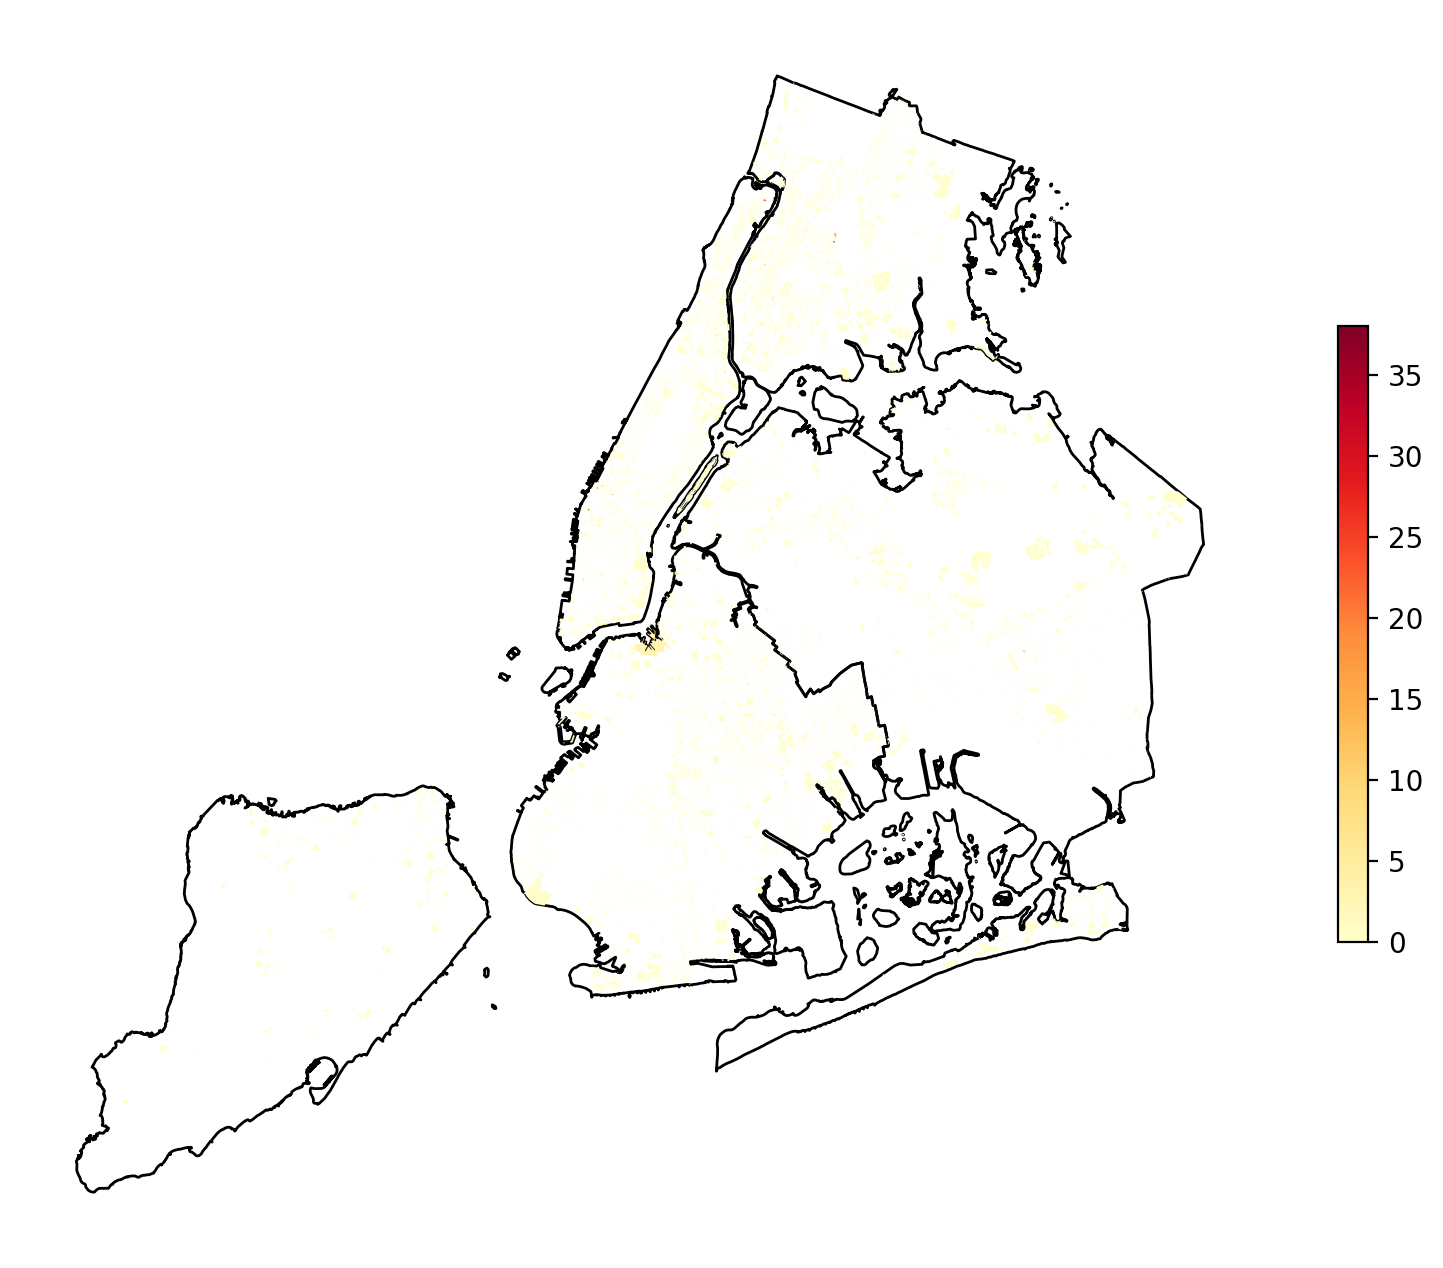

In [56]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
boros = read_parquet_from_github(
  "https://raw.githubusercontent.com/ds-20195/notebooks/main/notebook_data/Notebook8_NYC_boros.parquet"
).to_crs(2263)
boros.plot(ax=ax, facecolor="none")


nyc_evictions_count_pluto.plot(
    ax=ax,
    column="eviction_rate_bldg",
    vmin=0,
    legend=True,
    cmap="YlOrRd",
    legend_kwds={"shrink": 0.4},
)
ax.set_axis_off()

Hard to see what is going on here.

Let's try visualizing this better. We'll drop extreme outliers, and we'll change the size of points based on the eviction rate. We'll also use the building centroid.

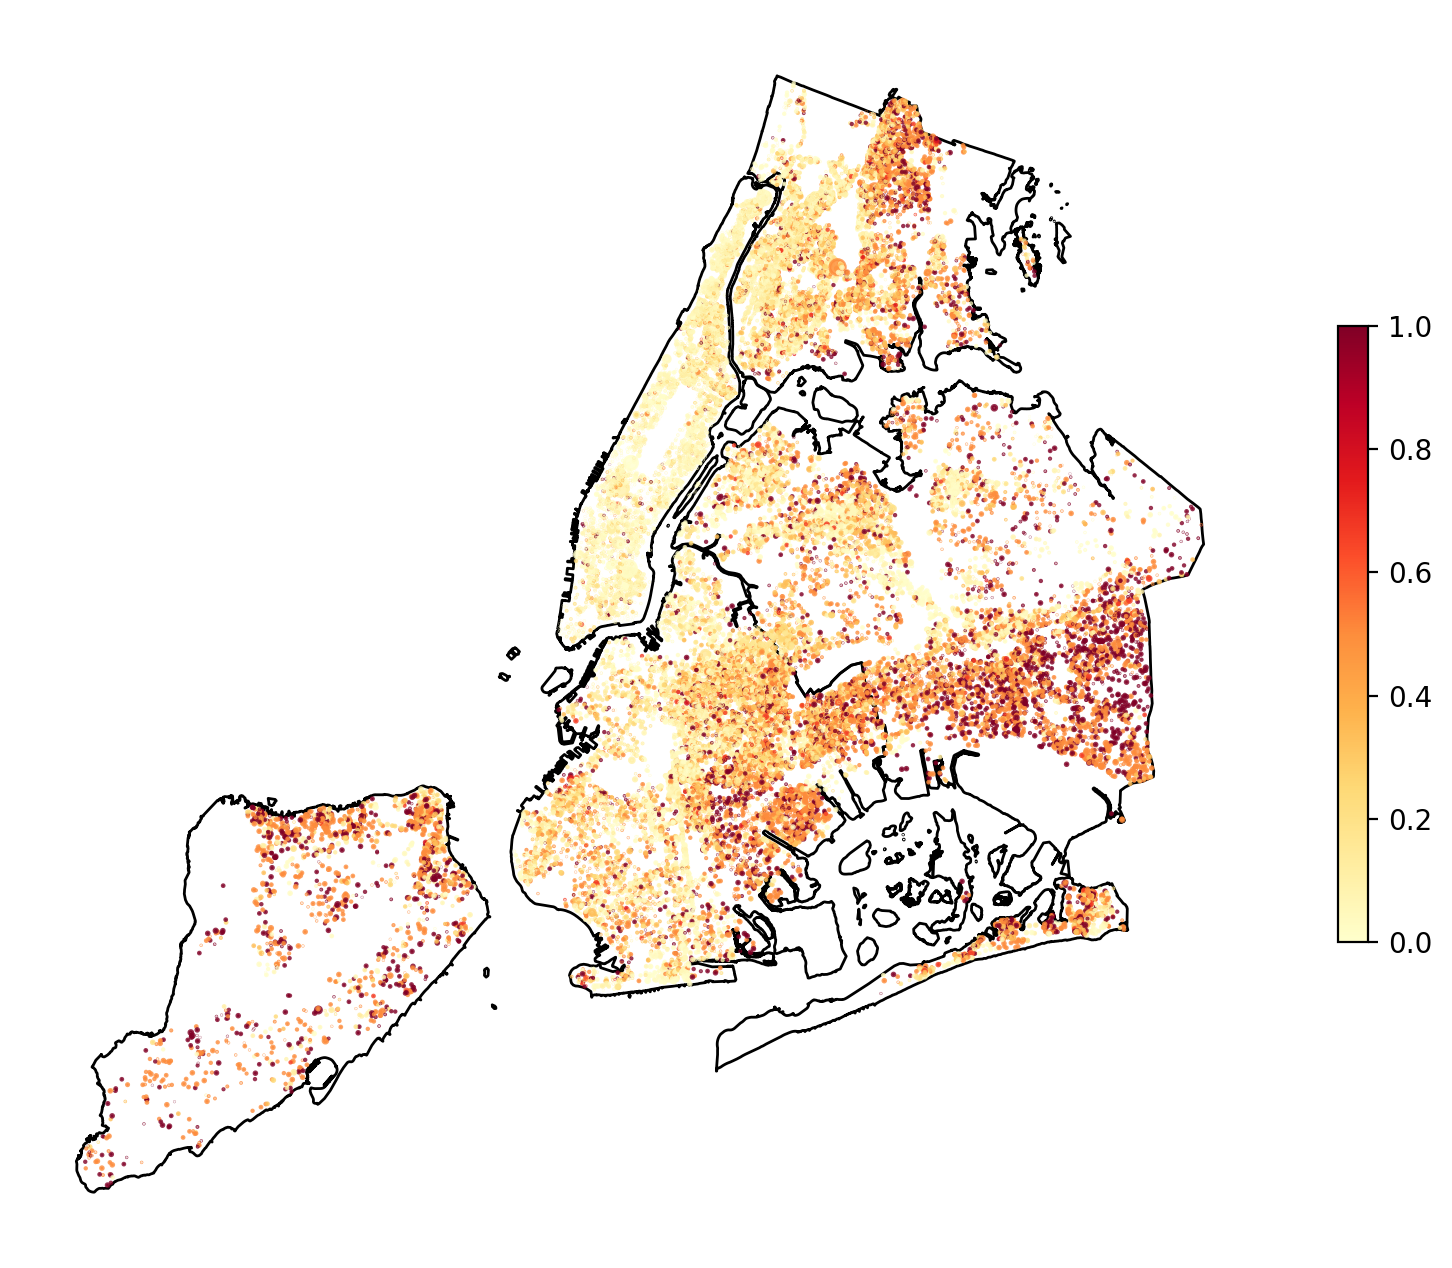

In [57]:
nyc_evictions_count_pluto["geometry"] = nyc_evictions_count_pluto["geometry"].centroid

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
boros.plot(ax=ax, facecolor="none")
nyc_evictions_count_pluto[
    nyc_evictions_count_pluto["eviction_rate_bldg"]
    <= nyc_evictions_count_pluto["eviction_rate_bldg"].quantile(0.95)
].plot(
    ax=ax,
    column="eviction_rate_bldg",
    markersize=nyc_evictions_count_pluto["eviction_rate_bldg"],
    vmin=0,
    alpha=0.8,
    legend=True,
    cmap="YlOrRd",
    legend_kwds={"shrink": 0.4},
)
ax.set_axis_off()

We can also make a heatmap using Folium.  We'll start with a dark basemap, but an alternative with a lighter basemap is provided as well.

In [58]:
map = folium.Map(location=[40.7, -73.97], tiles="Cartodb dark_matter", zoom_start=10)
#map = folium.Map(location=[40.7, -73.97], tiles="CartoDB positron", zoom_start=10)
heat_data = [
    [point.xy[1][0], point.xy[0][0]]
    for point in nyc_evictions_pluto_centroid.to_crs(4326).geometry
]

folium.plugins.HeatMap(heat_data, radius=20, blur=20, min_opacity=0.2).add_to(
    map,
)
map

# Homework 8 -- TBD